In [2]:
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from dotenv import load_dotenv
import os

from langchain_core.messages import AIMessageChunk

load_dotenv(override=True)
DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
DEEPSEEK_BASE_URL = "https://api.deepseek.com"
model = init_chat_model(
    model="deepseek:deepseek-v4-flash",
    api_key=DEEPSEEK_API_KEY,
    extra_body={"thinking": {"type": "disabled"}},  #关闭思考模式
)


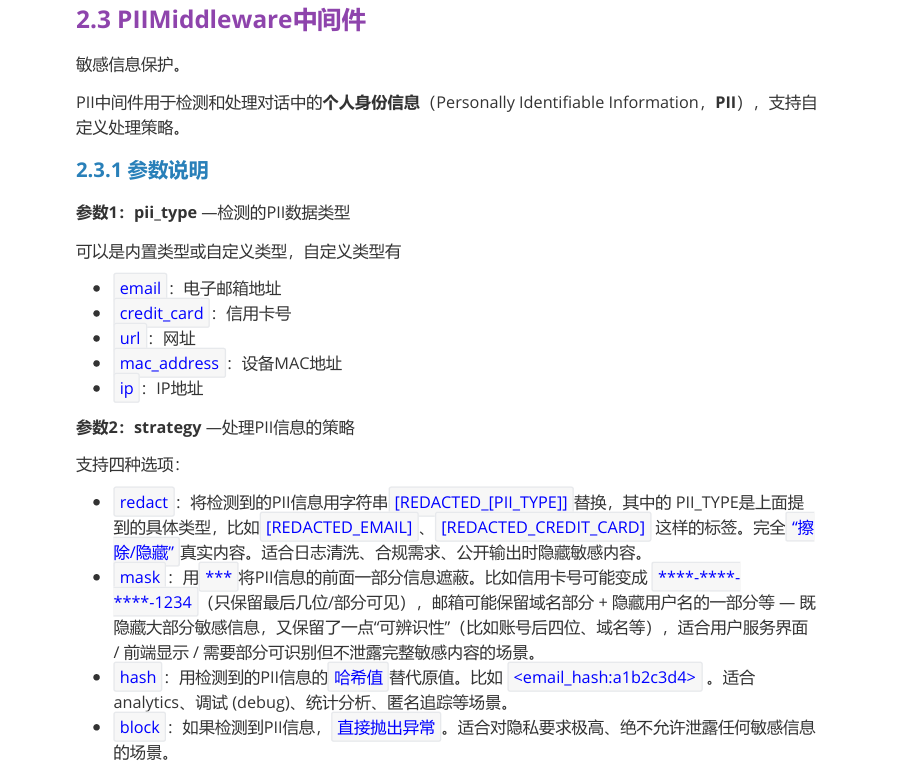
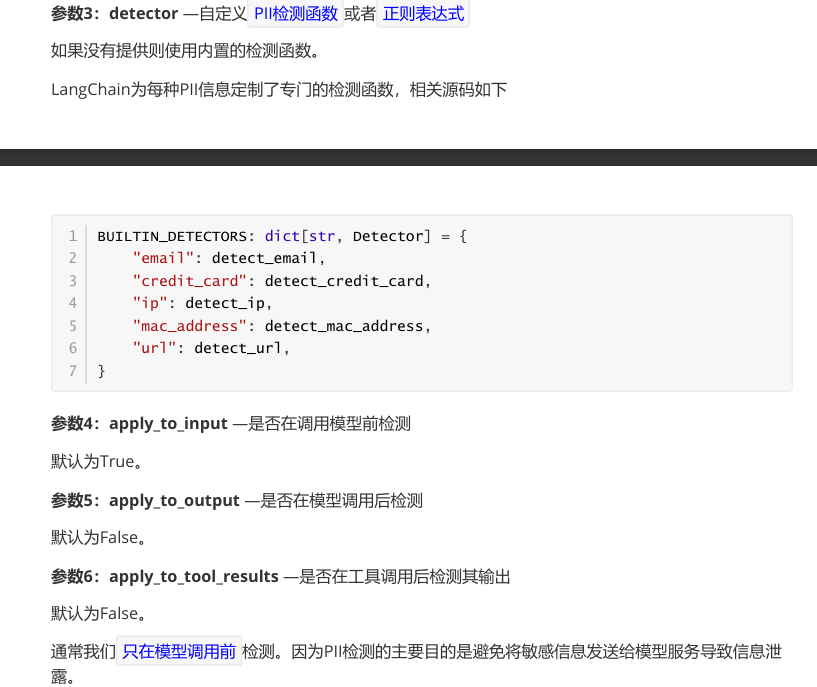

2.3.2 举例1：使用内置检测器

In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import PIIMiddleware
from langchain.messages import HumanMessage

agent = create_agent(
    model=model,
    tools=[],
    middleware=[
        PIIMiddleware("email", strategy="redact", apply_to_input=True),
        PIIMiddleware("credit_card", strategy="mask", apply_to_input=True),
        PIIMiddleware("url", strategy="hash", apply_to_input=True),
        PIIMiddleware("mac_address", strategy="mask", apply_to_input=True),
        PIIMiddleware("ip", strategy="block", apply_to_input=True),
    ]
)
response = agent.invoke({
    "messages": [HumanMessage("""
帮我向 156168188@qq.com 发送一封邮件
同时查看银行卡号： 5105-1051-0510-5100 的余额
访问 https://localhost:12345
确认这是不是 MAC地址： 11-11-11-11-11-11
""")]
})
for msg in response["messages"]:
    msg.pretty_print()
try:
    response1 = agent.invoke({
        "messages": [HumanMessage("看看这个 IP 能不能 ping 通：192.168.10.1")]
    })
except Exception as e:
    print('=' * 30, '-> 抛异常 <-', '=' * 30)
print(f"检测到IP，抛出异常：{e}")

2.3.3 举例2：自定义检测器/函数

In [3]:
import re


# 自定义检测函数
def detect_phone_number(content: str):
    return [
        {
            "text": m.group(0),  # 提取出具体匹配到的 11 位数字文本（例如 "13800138000"）
            "start": m.start(),  # 这段数字在原文本中的“起始索引位置”（从 0 开始算）
            "end": m.end()  # 这段数字在原文本中的“结束索引位置”
        } for m in re.finditer(r"[0-9]{11}", content)
    ]

测试：

In [4]:
text = "尚硅谷的电话是13812345678，康师傅的电话是13987654321。"
result = detect_phone_number(text)
print(result)

[{'text': '13812345678', 'start': 7, 'end': 18}, {'text': '13987654321', 'start': 26, 'end': 37}]


继续：

In [5]:
from langchain.agents import create_agent
from langchain.agents.middleware import PIIMiddleware
from langchain.messages import HumanMessage

agent = create_agent(
    model=model,
    tools=[],
    middleware=[
        PIIMiddleware("api_key", strategy="hash", apply_to_input=True,
                      detector=r"sk-[a-zA-Z0-9]+"),
        PIIMiddleware("phone_number", strategy="mask", apply_to_input=True,
                      detector=detect_phone_number)
    ]
)
response = agent.invoke({
    "messages": [HumanMessage("""
    这是不是有效的 API_KEY： sk-awef23AFEfaafaefa
    帮我给这个号码打电话： 12345612345
    访问 https://localhost:12345""")]
})
for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================


    这是不是有效的 API_KEY： <api_key_hash:6c678cc0>
    帮我给这个号码打电话： ****2345
    访问 https://localhost:12345
================================== Ai Message ==================================

我无法确认您提供的 API 密钥是否有效，因为`6c678cc0`看起来像是密钥的哈希值或部分内容，而不是完整的密钥。通常，有效的 API 密钥需要完整字符串并通过服务提供商验证。

另外，我无法帮您拨打任何电话号码，也无法访问您指定的本地地址（`https://localhost:12345`），因为这需要物理操作或网络访问权限，而我无法执行这些操作。

如果您有关于 API 密钥验证或电话号码使用的具体问题，请提供更多上下文，我将尽力提供帮助。
